# 1 minuto. Eso es lo que necesita esta IA para pronosticar los aerosoles del planeta entero.

Los modelos de pronóstico de calidad del aire que usamos hoy llevan décadas de desarrollo. Requieren supercomputadoras y horas de cálculo. Un equipo entrenó una red neuronal con 42 años de datos atmosféricos — y los resultados sugieren que puede igualar o superar a esos modelos.

---

**Paper:** Wei et al. (2026) *Machine-learning-driven global aerosol forecasting.* Nature.
**DOI:** [10.1038/s41586-026-10234-y](https://doi.org/10.1038/s41586-026-10234-y)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=vhKIxzk-eJo)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-12-ia-pronostico-aerosoles/notebook.ipynb)

## ¿Qué son los aerosoles y por qué importa pronosticarlos?

Los aerosoles son partículas suspendidas en la atmósfera: polvo del Sahara, hollín de incendios, sulfatos de la industria, sal marina. Afectan la salud (PM2,5), el clima (reflejan o absorben radiación) y la visibilidad.

El pronóstico de aerosoles es más difícil que el del tiempo: las partículas interactúan con la meteorología, se transforman químicamente en el aire y vienen de fuentes impredecibles (un incendio, una tormenta de arena). Por eso los modelos actuales — como **CAMS** (Copernicus) y **GEOS-FP** (NASA) — necesitan supercomputadoras y horas de cálculo.

**AI-GAMFS** (*Global Aerosol–Meteorology Forecasting System*) combina un Vision Transformer con U-Net, entrenado con 42 años de reanálisis MERRA-2. Veamos qué tan bien le va contra los modelos tradicionales.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HORIZONTE_MAX = 120          # Horizonte máximo de pronóstico (horas)
COLOR_GAMFS = '#2563EB'      # Azul CaM — AI-GAMFS
COLOR_CAMS = '#DC2626'       # Rojo — CAMS (Copernicus)
COLOR_GEOSFP = '#D97706'     # Amber — GEOS-FP (NASA)
COLOR_DUST = '#059669'       # Emerald — polvo (DUAOD)
FUENTE = 'Fuente: Wei et al. (2026), Nature | Datos: Source Data del paper'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
rend = pd.read_csv('datos/rendimiento_aeronet.csv')
mejora = pd.read_csv('datos/mejora_vs_cams.csv')
geosfp = pd.read_csv('datos/rmse_vs_geosfp.csv')
estaciones = pd.read_csv('datos/rmse_estaciones.csv')

print(f"Rendimiento AERONET: {len(rend)} puntos de pronóstico (cada 3h, hasta {rend['forecast_hours'].max()}h)")
print(f"Mejora vs CAMS: {len(mejora)} puntos × {len(mejora.columns)-1} componentes")
print(f"RMSE vs GEOS-FP: {len(geosfp)} puntos")
print(f"Estaciones AERONET: {estaciones['rmse_aod'].notna().sum()} con AOD")

Rendimiento AERONET: 40 puntos de pronóstico (cada 3h, hasta 120h)
Mejora vs CAMS: 40 puntos × 12 componentes
RMSE vs GEOS-FP: 40 puntos
Estaciones AERONET: 289 con AOD


## La prueba: AI-GAMFS vs CAMS

289 estaciones AERONET repartidas por el mundo midieron la realidad. Veamos quién acertó más.

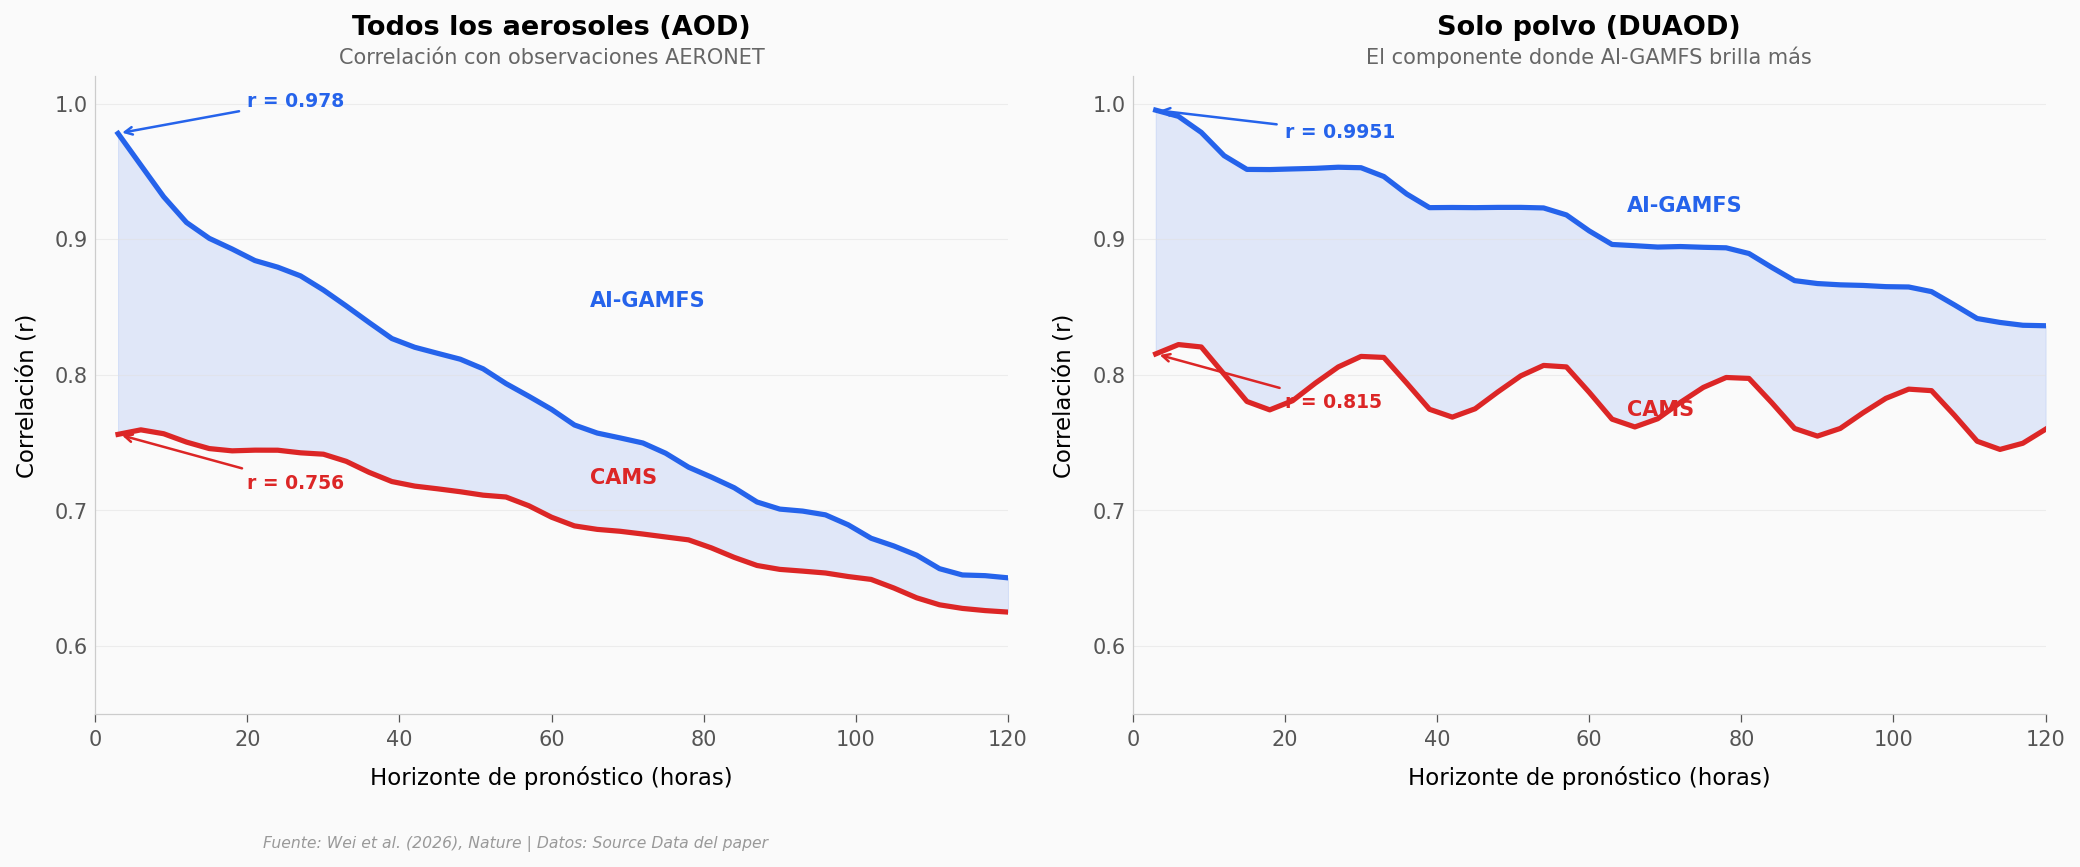

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

hours = rend['forecast_hours']

# ── Panel izquierdo: AOD (todos los aerosoles) ──
ax1.plot(hours, rend['r_aod_gamfs'], color=COLOR_GAMFS, linewidth=2.5, label='AI-GAMFS')
ax1.plot(hours, rend['r_aod_cams'], color=COLOR_CAMS, linewidth=2.5, label='CAMS')
ax1.fill_between(hours, rend['r_aod_cams'], rend['r_aod_gamfs'],
                 alpha=0.12, color=COLOR_GAMFS)
ax1.set_xlabel('Horizonte de pronóstico (horas)', fontsize=11)
ax1.set_ylabel('Correlación (r)', fontsize=11)
ax1.set_title('Todos los aerosoles (AOD)', fontsize=13, fontweight='bold', pad=20)
ax1.text(0.5, 1.02, 'Correlación con observaciones AERONET',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')
ax1.set_ylim(0.55, 1.02)
ax1.set_xlim(0, HORIZONTE_MAX)

# Inline labels
r3_g = rend.loc[rend['forecast_hours']==3, 'r_aod_gamfs'].values[0]
r3_c = rend.loc[rend['forecast_hours']==3, 'r_aod_cams'].values[0]
ax1.annotate(f'r = {r3_g:.3f}', xy=(3, r3_g), xytext=(20, r3_g+0.02),
             fontsize=9, fontweight='bold', color=COLOR_GAMFS,
             arrowprops=dict(arrowstyle='->', color=COLOR_GAMFS, lw=1.2))
ax1.annotate(f'r = {r3_c:.3f}', xy=(3, r3_c), xytext=(20, r3_c-0.04),
             fontsize=9, fontweight='bold', color=COLOR_CAMS,
             arrowprops=dict(arrowstyle='->', color=COLOR_CAMS, lw=1.2))
ax1.text(65, 0.85, 'AI-GAMFS', fontsize=10, fontweight='bold', color=COLOR_GAMFS)
ax1.text(65, 0.72, 'CAMS', fontsize=10, fontweight='bold', color=COLOR_CAMS)

# ── Panel derecho: DUAOD (polvo) ──
ax2.plot(hours, rend['r_duaod_gamfs'], color=COLOR_GAMFS, linewidth=2.5)
ax2.plot(hours, rend['r_duaod_cams'], color=COLOR_CAMS, linewidth=2.5)
ax2.fill_between(hours, rend['r_duaod_cams'], rend['r_duaod_gamfs'],
                 alpha=0.12, color=COLOR_GAMFS)
ax2.set_xlabel('Horizonte de pronóstico (horas)', fontsize=11)
ax2.set_ylabel('Correlación (r)', fontsize=11)
ax2.set_title('Solo polvo (DUAOD)', fontsize=13, fontweight='bold', pad=20)
ax2.text(0.5, 1.02, 'El componente donde AI-GAMFS brilla más',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')
ax2.set_ylim(0.55, 1.02)
ax2.set_xlim(0, HORIZONTE_MAX)

r3_dg = rend.loc[rend['forecast_hours']==3, 'r_duaod_gamfs'].values[0]
r3_dc = rend.loc[rend['forecast_hours']==3, 'r_duaod_cams'].values[0]
ax2.annotate(f'r = {r3_dg:.4f}', xy=(3, r3_dg), xytext=(20, r3_dg-0.02),
             fontsize=9, fontweight='bold', color=COLOR_GAMFS,
             arrowprops=dict(arrowstyle='->', color=COLOR_GAMFS, lw=1.2))
ax2.annotate(f'r = {r3_dc:.3f}', xy=(3, r3_dc), xytext=(20, r3_dc-0.04),
             fontsize=9, fontweight='bold', color=COLOR_CAMS,
             arrowprops=dict(arrowstyle='->', color=COLOR_CAMS, lw=1.2))
ax2.text(65, 0.92, 'AI-GAMFS', fontsize=10, fontweight='bold', color=COLOR_GAMFS)
ax2.text(65, 0.77, 'CAMS', fontsize=10, fontweight='bold', color=COLOR_CAMS)

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/correlacion_aod.png', dpi=200, bbox_inches='tight')
plt.show()

A 3 horas, la diferencia en AOD es enorme: r = 0,978 vs 0,756. A 5 días (120h), ambos convergen — el caos atmosférico impone un límite. Pero durante ese recorrido, AI-GAMFS mantiene una ventaja consistente.

Pero el polvo (tormentas de arena, Sahara, incendios) es donde AI-GAMFS arranca con r = 0,9951. Casi perfecto.

⚠️ **Nota de certeza:** estos datos son del periodo de validación con reanálisis (condiciones ideales). El abstract dice que la comparación *"suggests improved performance"* — no afirma superioridad absoluta. En operación real la ventaja es menor (pero consistente).

## ¿En qué componentes mejora más?

Los aerosoles no son una sola cosa. AOD (profundidad óptica de aerosoles) es el total, pero dentro hay polvo, hollín, sulfatos, sal marina y carbón orgánico. Veamos dónde AI-GAMFS gana — y dónde no.

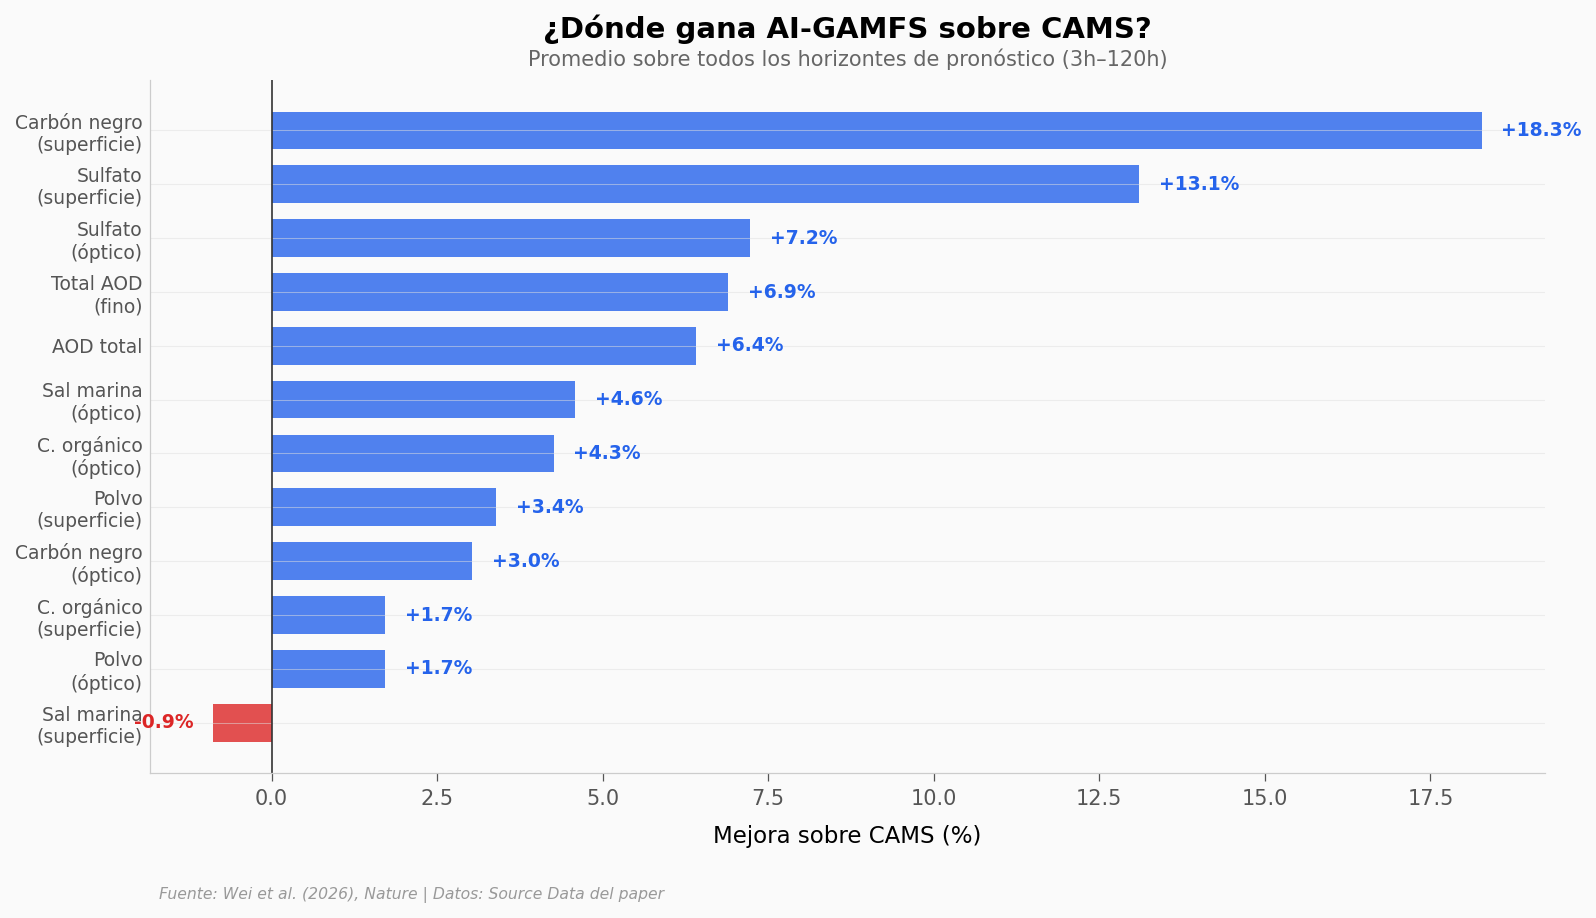

In [3]:
# Mejora promedio por componente (media sobre todos los horizontes)
components = {
    'BCSMC': ('Carbón negro\n(superficie)', mejora['bcsmc'].mean()),
    'SUSMC': ('Sulfato\n(superficie)', mejora['susmc'].mean()),
    'SUAOD': ('Sulfato\n(óptico)', mejora['suaod'].mean()),
    'TSAOD': ('Total AOD\n(fino)', mejora['tsaod'].mean()),
    'AOD': ('AOD total', mejora['aod'].mean()),
    'SSAOD': ('Sal marina\n(óptico)', mejora['ssaod'].mean()),
    'OCAOD': ('C. orgánico\n(óptico)', mejora['ocaod'].mean()),
    'DUSMC': ('Polvo\n(superficie)', mejora['dusmc'].mean()),
    'BCAOD': ('Carbón negro\n(óptico)', mejora['bcaod'].mean()),
    'DUAOD': ('Polvo\n(óptico)', mejora['duaod'].mean()),
    'OCSMC': ('C. orgánico\n(superficie)', mejora['ocsmc'].mean()),
    'SSSMC': ('Sal marina\n(superficie)', mejora['sssmc'].mean()),
}

names = list(components.keys())
labels = [components[n][0] for n in names]
values = [components[n][1] for n in names]

# Sort by value
order = np.argsort(values)[::-1]
labels_sorted = [labels[i] for i in order]
values_sorted = [values[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 6))
colors = [COLOR_GAMFS if v > 0 else COLOR_CAMS for v in values_sorted]
bars = ax.barh(range(len(values_sorted)), values_sorted, color=colors, alpha=0.8, height=0.7)

# Inline values
for i, (val, bar) in enumerate(zip(values_sorted, bars)):
    offset = 0.3 if val > 0 else -0.3
    ha = 'left' if val > 0 else 'right'
    ax.text(val + offset, i, f'{val:+.1f}%', va='center', ha=ha,
            fontsize=9, fontweight='bold', color=colors[i])

ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=9)
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_xlabel('Mejora sobre CAMS (%)', fontsize=11)
ax.set_title('¿Dónde gana AI-GAMFS sobre CAMS?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Promedio sobre todos los horizontes de pronóstico (3h–120h)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.invert_yaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mejora_componentes.png', dpi=200, bbox_inches='tight')
plt.show()

La ventaja más grande está en las concentraciones superficiales de carbón negro (+18,3%) y sulfato (+13,1%). No sorprende: las concentraciones en superficie son más difíciles de pronosticar con modelos físicos porque dependen de procesos locales (emisiones, deposición, mezcla en la capa límite) que los modelos globales resuelven mal.

¿La sal marina en superficie? AI-GAMFS pierde por poco (−0,9%). No todo es victoria.

## Comparación con GEOS-FP: concentraciones en superficie

GEOS-FP es el modelo operativo de la NASA — el que inicializa los pronósticos diarios. Veamos cómo le va a AI-GAMFS contra él en lo que más importa para la salud: las concentraciones que respiramos.

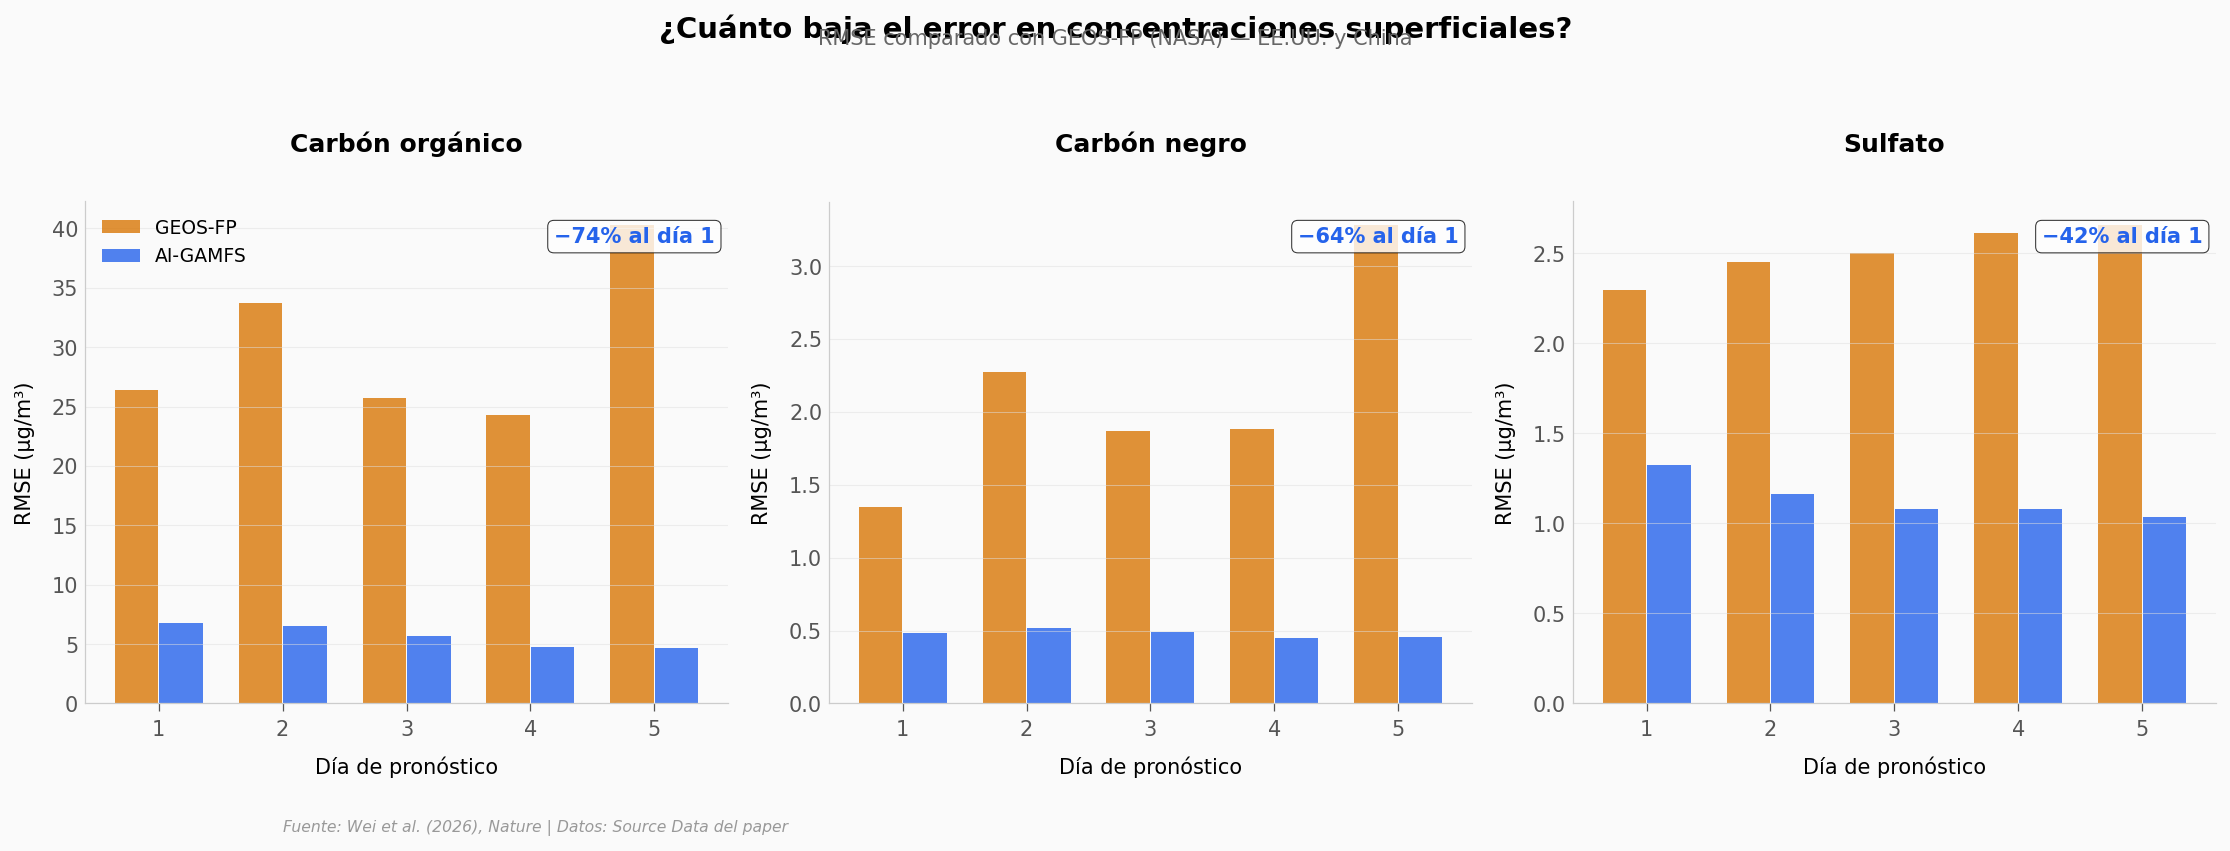

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

components_gf = [
    ('Carbón orgánico', 'rmse_ocsmc_geosfp', 'rmse_ocsmc_gamfs', 'µg/m³'),
    ('Carbón negro', 'rmse_bcsmc_geosfp', 'rmse_bcsmc_gamfs', 'µg/m³'),
    ('Sulfato', 'rmse_susmc_geosfp', 'rmse_susmc_gamfs', 'µg/m³'),
]

days = geosfp['forecast_days'].dropna().astype(int)

for ax, (name, col_gf, col_gm, unit) in zip(axes, components_gf):
    vals_gf = geosfp.loc[geosfp['forecast_days'].notna(), col_gf].values[:len(days)]
    vals_gm = geosfp.loc[geosfp['forecast_days'].notna(), col_gm].values[:len(days)]
    
    ax.bar(days - 0.18, vals_gf, width=0.35, color=COLOR_GEOSFP, alpha=0.8, label='GEOS-FP')
    ax.bar(days + 0.18, vals_gm, width=0.35, color=COLOR_GAMFS, alpha=0.8, label='AI-GAMFS')
    
    # Reduction at day 1
    red = (1 - vals_gm[0] / vals_gf[0]) * 100
    ax.text(0.98, 0.95, f'−{red:.0f}% al día 1',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=COLOR_GAMFS, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Día de pronóstico', fontsize=10)
    ax.set_ylabel(f'RMSE ({unit})', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xticks(days)

# Legend only on first panel
axes[0].legend(fontsize=9, loc='upper left')

fig.suptitle('¿Cuánto baja el error en concentraciones superficiales?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'RMSE comparado con GEOS-FP (NASA) — EE.UU. y China',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rmse_geosfp.png', dpi=200, bbox_inches='tight')
plt.show()

El carbón orgánico es donde la diferencia es brutal: AI-GAMFS reduce el error un 74% al día 1. Para el carbón negro, 64%. Para el sulfato, 42%. Y esa ventaja se mantiene durante los 5 días de pronóstico.

## ¿Es consistente en todo el mundo?

Una cosa es el promedio global. Otra es si AI-GAMFS gana en la mayoría de las estaciones o solo en algunas favorables. Veamos la distribución estación por estación.

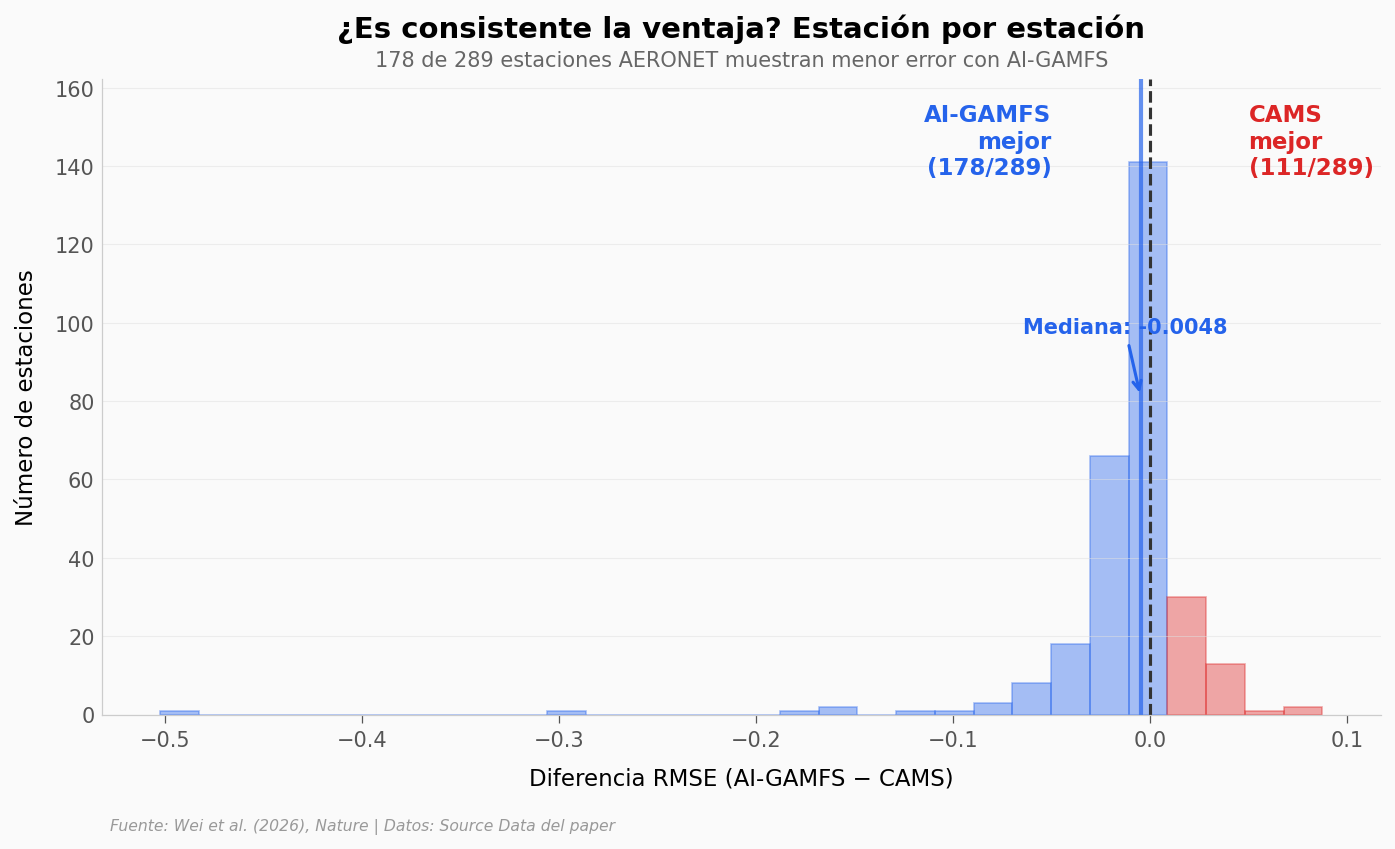

In [5]:
diff_aod = estaciones['rmse_aod_diff_vs_cams'].dropna()
n_better = (diff_aod < 0).sum()
n_total = len(diff_aod)

fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, patches = ax.hist(diff_aod, bins=30, color=COLOR_GAMFS, alpha=0.4,
                           edgecolor=COLOR_GAMFS, linewidth=0.8)

# Color bars: blue if better, red if worse
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 0:
        patch.set_facecolor(COLOR_CAMS)
        patch.set_edgecolor(COLOR_CAMS)
        patch.set_alpha(0.4)

ax.axvline(0, color='#333333', linewidth=1.5, linestyle='--')
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Annotations
ax.text(-0.05, y_max * 0.85, f'AI-GAMFS\nmejor\n({n_better}/{n_total})',
        fontsize=11, fontweight='bold', color=COLOR_GAMFS, ha='right')
ax.text(0.05, y_max * 0.85, f'CAMS\nmejor\n({n_total - n_better}/{n_total})',
        fontsize=11, fontweight='bold', color=COLOR_CAMS, ha='left')

# Median
med = diff_aod.median()
ax.axvline(med, color=COLOR_GAMFS, linewidth=2, alpha=0.7)
ax.annotate(f'Mediana: {med:.4f}', xy=(med, y_max*0.5),
            xytext=(med-0.06, y_max*0.6),
            fontsize=10, fontweight='bold', color=COLOR_GAMFS,
            arrowprops=dict(arrowstyle='->', color=COLOR_GAMFS, lw=1.5))

ax.set_xlabel('Diferencia RMSE (AI-GAMFS − CAMS)', fontsize=11)
ax.set_ylabel('Número de estaciones', fontsize=11)
ax.set_title('¿Es consistente la ventaja? Estación por estación',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{n_better} de {n_total} estaciones AERONET muestran menor error con AI-GAMFS',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_estaciones.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| AI-GAMFS tiene correlación más alta que CAMS en AOD | ✅ | r = 0,978 vs 0,756 a 3h (periodo de reanálisis). Ventaja se reduce con el horizonte pero se mantiene hasta 120h |
| En polvo (DUAOD) la correlación es casi perfecta | ✅ | r = 0,9951 a 3h. A 120h baja a 0,836 pero sigue superando a CAMS (0,760) |
| AI-GAMFS reduce el RMSE un 72% en AOD a 3h | ✅ | RMSE = 0,0305 vs 0,1096 (CAMS). Ratio = 0,278 |
| Las concentraciones superficiales mejoran hasta 74% vs GEOS-FP | ✅ | Carbón orgánico: RMSE 6,74 vs 26,41 (−74,5% al día 1) |
| AI-GAMFS gana en la mayoría de estaciones | ⚠️ | 178/289 (61,6%) para AOD. Para polvo: 243/289 (84,1%). No es unánime en AOD |
| Sal marina en superficie no mejora | ✅ | SSSMC: −0,9% sobre CAMS (único componente negativo) |

> **Limitaciones:** (1) La comparación con r más alto (Fig. 2a) es con el modelo entrenado con reanálisis, no el operacional. En condiciones operacionales la ventaja es menor. (2) Los datos son de estaciones AERONET (tierra firme) — no hay validación oceánica directa. (3) El paper usa *"suggests improved"* — la superioridad depende del periodo y la métrica.

---

## Ahora tú

1. **¿Cuántas horas de ventaja tiene AI-GAMFS?** Si definimos "ventaja" como `r_GAMFS - r_CAMS > 0.05`, ¿hasta qué horizonte se mantiene para AOD? ¿Y para polvo?
2. **¿Dónde falla AI-GAMFS?** En los datos de estaciones, ¿hay algún patrón geográfico (latitud, longitud) en las estaciones donde CAMS gana?
3. **Cambia `HORIZONTE_MAX`** en la celda de configuración a 48 horas — ¿cómo se ven las curvas en el rango operativo más común?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Hasta qué horizonte AI-GAMFS tiene ventaja clara (>0.05) sobre CAMS?

umbral = 0.05  # Diferencia mínima en r para considerar ventaja

diff_aod = rend['r_aod_gamfs'] - rend['r_aod_cams']
diff_duaod = rend['r_duaod_gamfs'] - rend['r_duaod_cams']

# Encontrar último horizonte con ventaja > umbral
ultimo_aod = rend.loc[diff_aod > umbral, 'forecast_hours'].max()
ultimo_duaod = rend.loc[diff_duaod > umbral, 'forecast_hours'].max()

print(f"Ventaja de AI-GAMFS (Δr > {umbral}):")
print(f"  AOD:   hasta {ultimo_aod}h ({ultimo_aod/24:.1f} días)")
print(f"  DUAOD: hasta {ultimo_duaod}h ({ultimo_duaod/24:.1f} días)")
print()
print(f"Diferencia media por tramo:")
for start, end, label in [(3, 24, 'Día 1'), (24, 48, 'Día 2'), (48, 120, 'Días 3-5')]:
    mask = (rend['forecast_hours'] >= start) & (rend['forecast_hours'] <= end)
    d_aod = diff_aod[mask].mean()
    d_dust = diff_duaod[mask].mean()
    print(f"  {label:10}: AOD Δr = {d_aod:+.3f}   DUAOD Δr = {d_dust:+.3f}")

Ventaja de AI-GAMFS (Δr > 0.05):
  AOD:   hasta 84h (3.5 días)
  DUAOD: hasta 120h (5.0 días)

Diferencia media por tramo:
  Día 1     : AOD Δr = +0.167   DUAOD Δr = +0.168
  Día 2     : AOD Δr = +0.113   DUAOD Δr = +0.145
  Días 3-5  : AOD Δr = +0.054   DUAOD Δr = +0.103


---

**Datos:** Source Data de Wei et al. (2026), Nature. Descargados del Supplementary Materials del paper.
**Paper:** [10.1038/s41586-026-10234-y](https://doi.org/10.1038/s41586-026-10234-y)
**Código AI-GAMFS:** [Zenodo 18298799](https://zenodo.org/records/18298799)
**Licencia:** Los datos del paper mantienen su licencia original (Nature Supplementary). Notebook: [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)